<span style='font-size:x-large'>**Energy Insecurity Capstone Project**</span>

Author: Hilary Griggs 

Date: 2025\-2026

<span style='font-size:large'>Environmental Research Question: </span>

How has household energy insecurity changed over time in the United States, and how does it differ across income groups?

Link to GitHub repository: [https://github.com/hilarybg/energy\-insecurity](https://github.com/hilarybg/energy-insecurity) 


In [20]:
import pandas as pd

#load data
df_2024 = pd.read_excel("../data/raw/eia_recs_2024.xlsx")

df_2024.head()

,Preliminary data release date: March 2026,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"Table HC11.1 Household energy insecurity, 2024",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Number of housing units (million),NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Households reporting...,NaN,NaN,NaN,NaN,NaN
3,NaN,Total U.S.a,Any household energy insecurityb,Reducing or forgoing food or medicine to pay e...,Leaving home at unhealthy temperature,Receiving disconnect or delivery stop notice,Unable to use heating equipmentc,Unable to use air-conditioning equipmentd
4,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16


In [21]:
#inspect columns and rows 
df_2024.columns
df_2024.head(10)

,Preliminary data release date: March 2026,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"Table HC11.1 Household energy insecurity, 2024",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Number of housing units (million),NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Households reporting...,NaN,NaN,NaN,NaN,NaN
3,NaN,Total U.S.a,Any household energy insecurityb,Reducing or forgoing food or medicine to pay e...,Leaving home at unhealthy temperature,Receiving disconnect or delivery stop notice,Unable to use heating equipmentc,Unable to use air-conditioning equipmentd
4,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
5,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
7,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
8,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83
9,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52


In [22]:
#fix which row is functioning as header 
df_2024 = pd.read_excel("../data/raw/eia_recs_2024.xlsx", header=3)

# Drop empty rows
df_2024 = df_2024[df_2024.iloc[:,0].notna()]

# Rename first column
df_2024 = df_2024.rename(columns={df_2024.columns[0]: "Region"})

df_2024.head()


,Region,Unnamed: 1,Households reporting...,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83


In [23]:
#look at column names
list(df_2024.columns)


['Region',
 'Unnamed: 1',
 'Households reporting...',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7']

In [24]:
#inspect real header rows
df_2024.head(8)

,Region,Unnamed: 1,Households reporting...,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83
6,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52
7,East North Central,19.47,5.97,4.43,2.15,2.32,0.88,0.95
8,West North Central,9.02,2.55,1.85,1.01,1.05,0.47,0.57


In [25]:
#rename columns
df_2024.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]

df_2024.head()

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83


In [26]:
# Remove blank and section-header rows
df_2024 = df_2024[df_2024["region"].notna()]
df_2024 = df_2024[df_2024["region"] != "Census region and division"]

# Add year 
df_2024["year"] = 2024

# Preview 
df_2024.head(10)

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac,year
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16,2024
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16,2024
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34,2024
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83,2024
6,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52,2024
7,East North Central,19.47,5.97,4.43,2.15,2.32,0.88,0.95,2024
8,West North Central,9.02,2.55,1.85,1.01,1.05,0.47,0.57,2024
9,South,51.49,18.25,14.11,6.73,7.39,3.23,3.81,2024
10,South Atlantic,27.38,8.76,6.67,3.27,3.31,1.41,1.69,2024
11,East South Central,8.01,3.11,2.34,1.31,1.19,0.78,0.79,2024


In [27]:
#check data types 
df_2024.info()


<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 1 to 96
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   region                     94 non-null     object
 1   total_households_million   79 non-null     object
 2   any_insecurity             79 non-null     object
 3   food_or_medicine_tradeoff  79 non-null     object
 4   unsafe_temperature         79 non-null     object
 5   disconnect_notice          79 non-null     object
 6   no_heating                 79 non-null     object
 7   no_ac                      79 non-null     object
 8   year                       94 non-null     int64 
dtypes: int64(1), object(8)
memory usage: 7.3+ KB


In [28]:
# Convert the numeric columns that are showing as objects 
num_cols = [
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]

for col in num_cols:
    df_2024[col] = pd.to_numeric(df_2024[col], errors="coerce")

df_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 1 to 96
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   region                     94 non-null     object 
 1   total_households_million   79 non-null     float64
 2   any_insecurity             78 non-null     float64
 3   food_or_medicine_tradeoff  78 non-null     float64
 4   unsafe_temperature         78 non-null     float64
 5   disconnect_notice          78 non-null     float64
 6   no_heating                 76 non-null     float64
 7   no_ac                      76 non-null     float64
 8   year                       94 non-null     int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 7.3+ KB


In [29]:
# Repeat this process for 2020 data 
df_2020 = pd.read_excel("../data/raw/eia_recs_2020.xlsx", header=3)
df_2020.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]
df_2020 = df_2020[df_2020["region"].notna()]
df_2020 = df_2020[df_2020["region"] != "Census region and division"]
df_2020["year"] = 2020

for col in num_cols:
    df_2020[col] = pd.to_numeric(df_2020[col], errors="coerce")

In [30]:
#Repeat this process for 2015 data 
df_2015 = pd.read_excel("../data/raw/eia_recs_2015.xlsx", header=3)
df_2015.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]
df_2015 = df_2015[df_2015["region"].notna()]
df_2015 = df_2015[df_2015["region"] != "Census region and division"]
df_2015["year"] = 2015

for col in num_cols:
    df_2015[col] = pd.to_numeric(df_2015[col], errors="coerce")

In [31]:
# Combine the three years 
df_all = pd.concat([df_2015, df_2020, df_2024], ignore_index=True)
df_all.head()

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac,year
0,All homes,118.2,37.0,25.3,12.8,17.2,6.1,6.9,2015
1,Northeast,21.0,6.2,4.0,2.5,2.7,1.4,0.6,2015
2,New England,5.6,2.0,1.2,0.8,0.9,0.4,0.4,2015
3,Middle Atlantic,15.4,4.1,2.8,1.7,1.8,1.0,0.2,2015
4,Midwest,26.4,7.4,5.0,2.2,3.8,1.1,1.1,2015


In [32]:
# Save cleaned dataset
df_all.to_csv("../data/processed/energy_insecurity_cleaned.csv", index=False)

<span style='font-size:x-large'>Visualizations </span>

<span style='font-size:small'>This section creates a series of visualizations representing the data. </span>


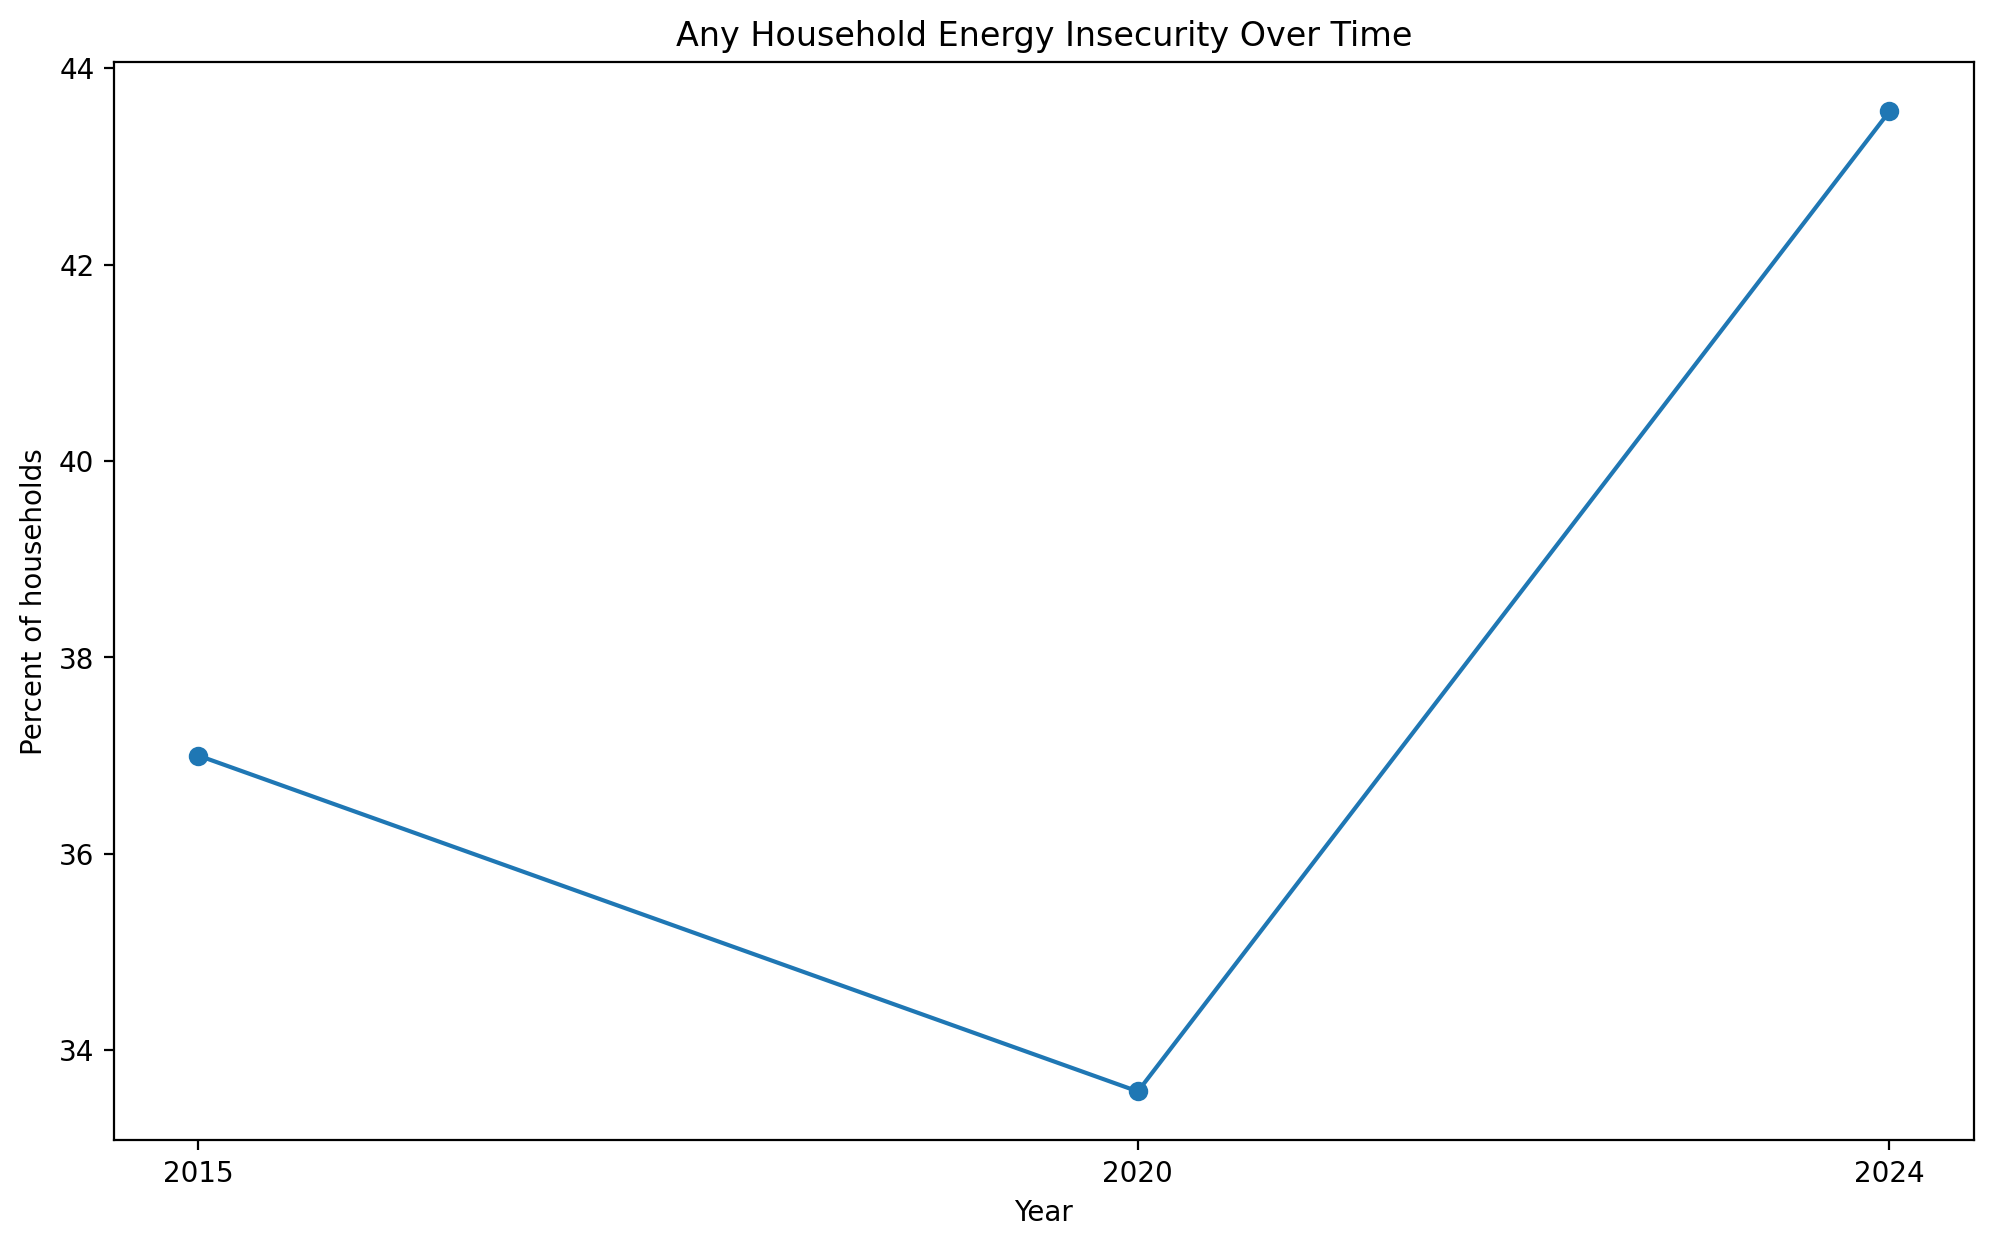

In [33]:
# Inspect national trends 

import matplotlib.pyplot as plt

df_us = df_all[df_all["region"] == "All homes"]

plt.plot(df_us["year"], df_us["any_insecurity"], marker="o")
plt.title("Any Household Energy Insecurity Over Time")
plt.xlabel("Year")
plt.ylabel("Percent of households")
plt.xticks([2015, 2020, 2024])
plt.show()


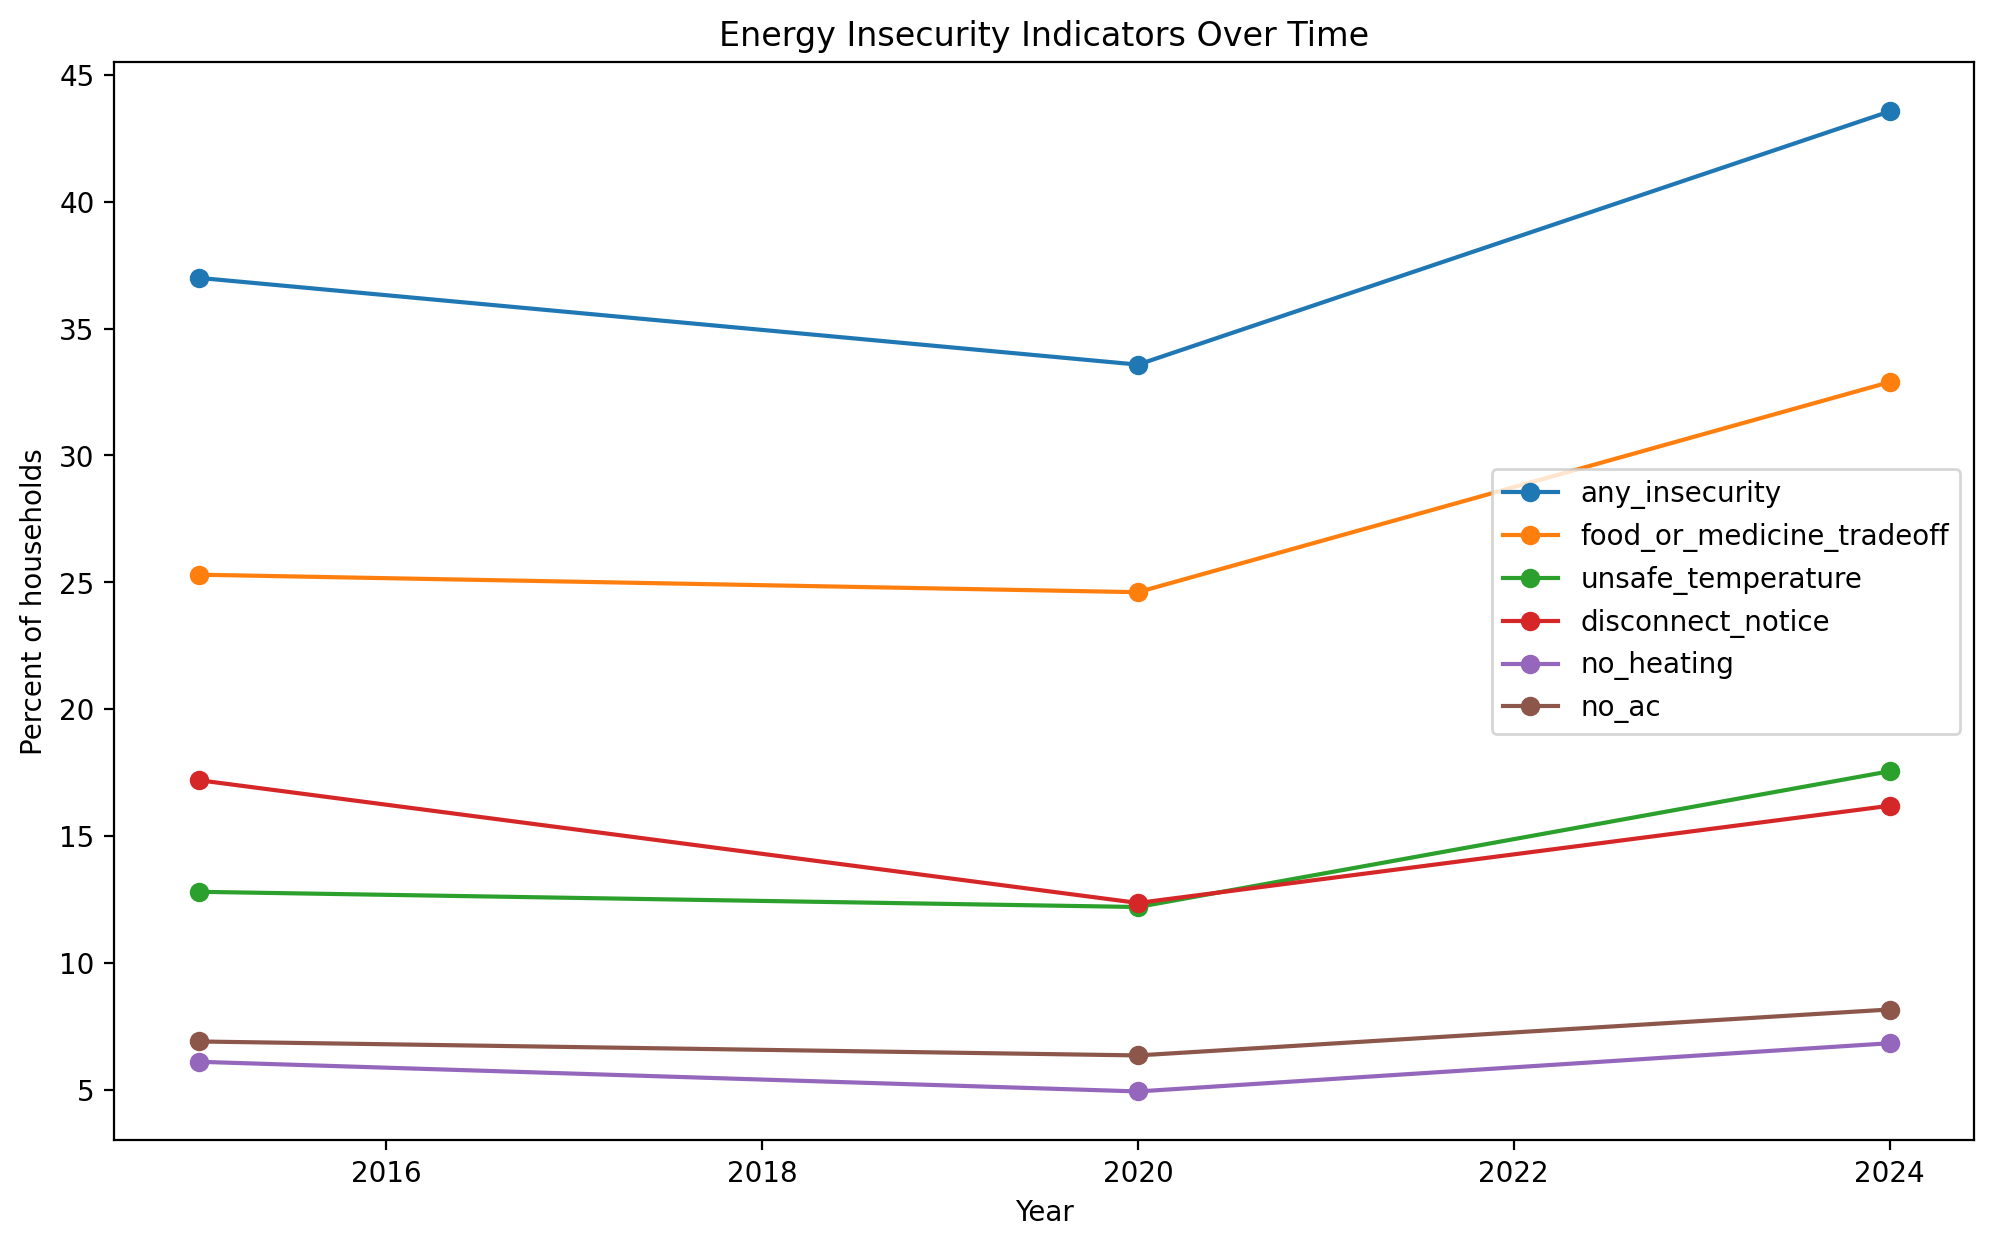

In [34]:
# Compare all metrics 

import matplotlib.pyplot as plt

df_us = df_all[df_all["region"] == "All homes"]

metrics = [
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]

for metric in metrics:
    plt.plot(df_us["year"], df_us[metric], marker="o", label=metric)

plt.title("Energy Insecurity Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Percent of households")
plt.legend()
plt.show()

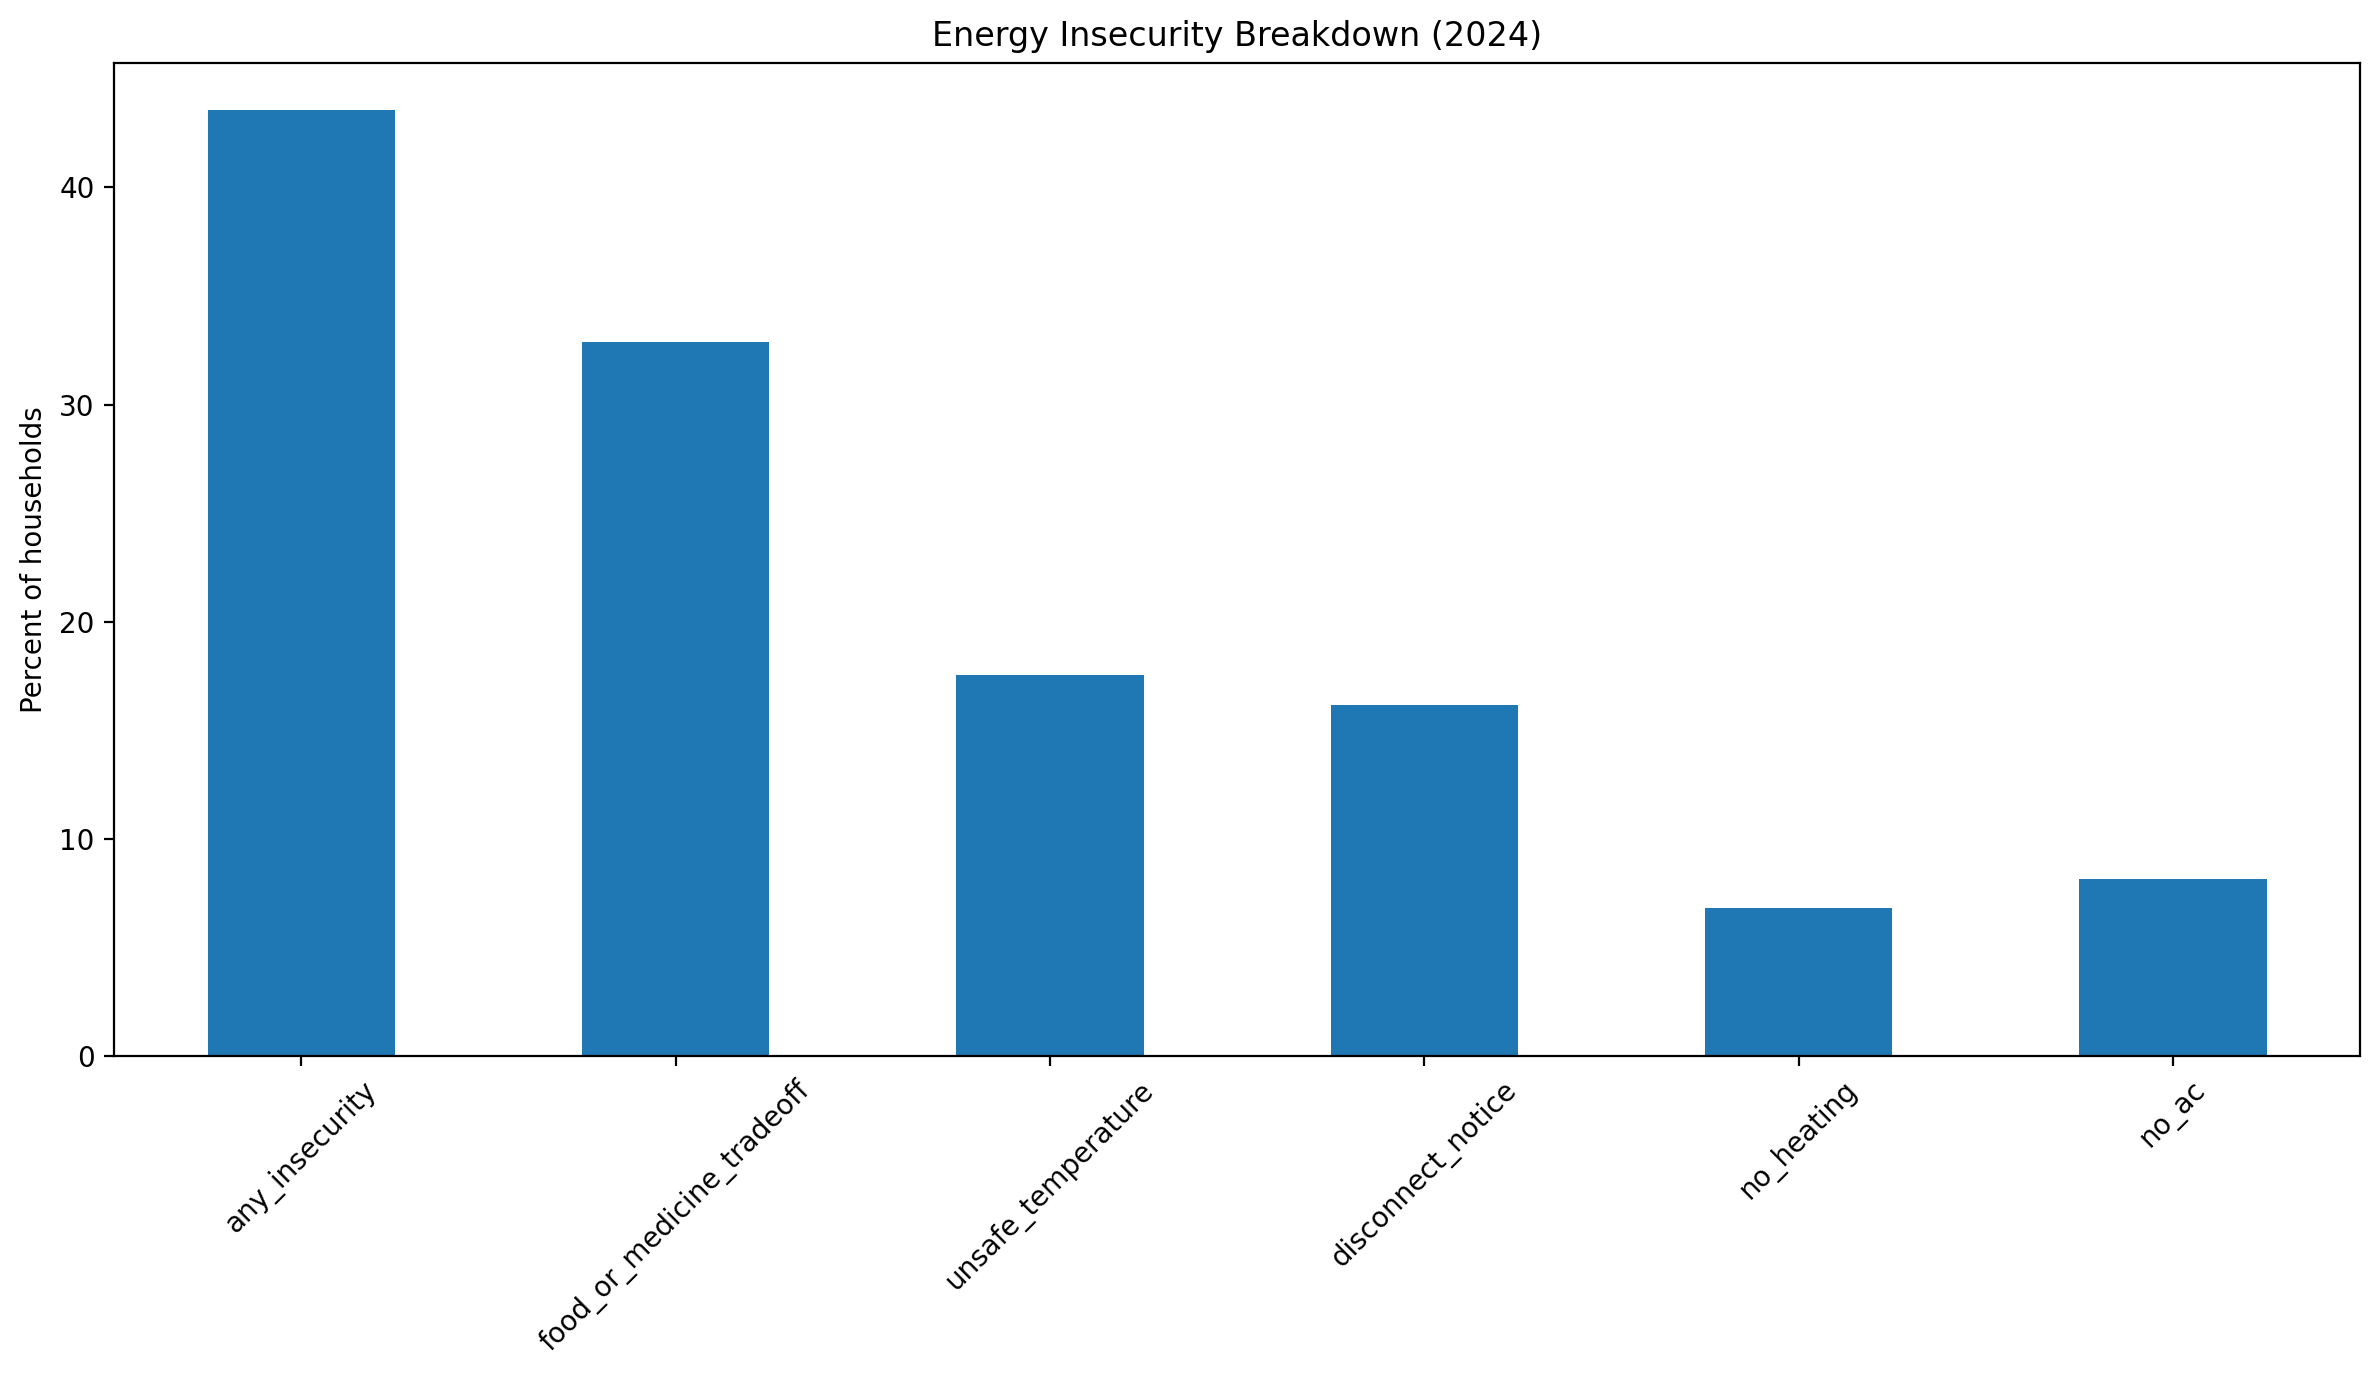

In [35]:
# Compare the metrics from the most recent survey 
df_2024_us = df_all[(df_all["year"] == 2024) & (df_all["region"] == "All homes")]

df_2024_us[metrics].T.plot(kind="bar", legend=False)

plt.title("Energy Insecurity Breakdown (2024)")
plt.ylabel("Percent of households")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

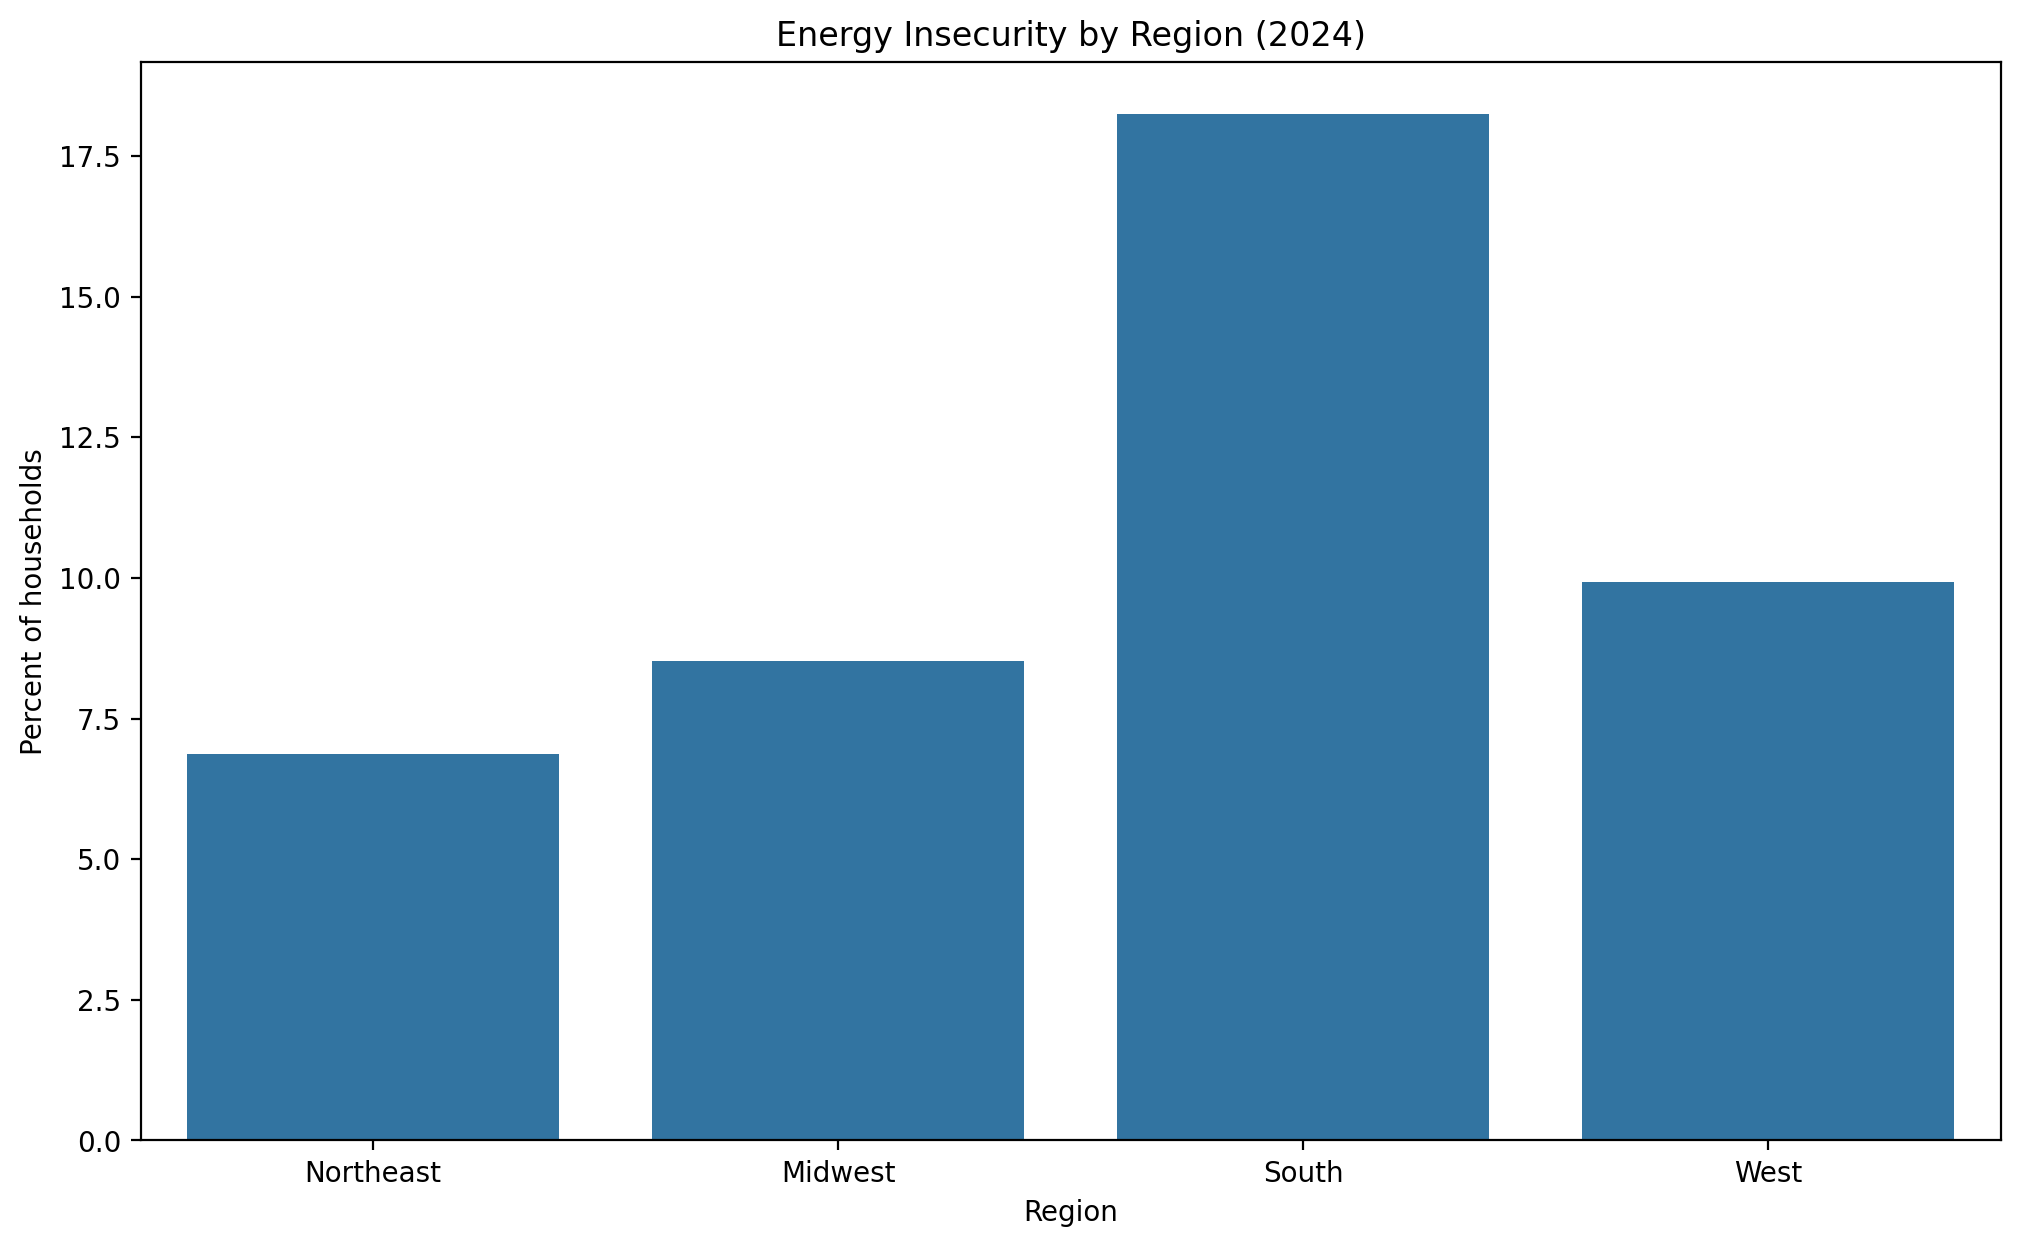

In [37]:
# Compare regions 
regions = ["Northeast", "Midwest", "South", "West"]

df_regions_2024 = df_all[
    (df_all["year"] == 2024) & 
    (df_all["region"].isin(regions))
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df_regions_2024,
    x="region",
    y="any_insecurity"
)

plt.title("Energy Insecurity by Region (2024)")
plt.xlabel("Region")
plt.ylabel("Percent of households")
plt.show()

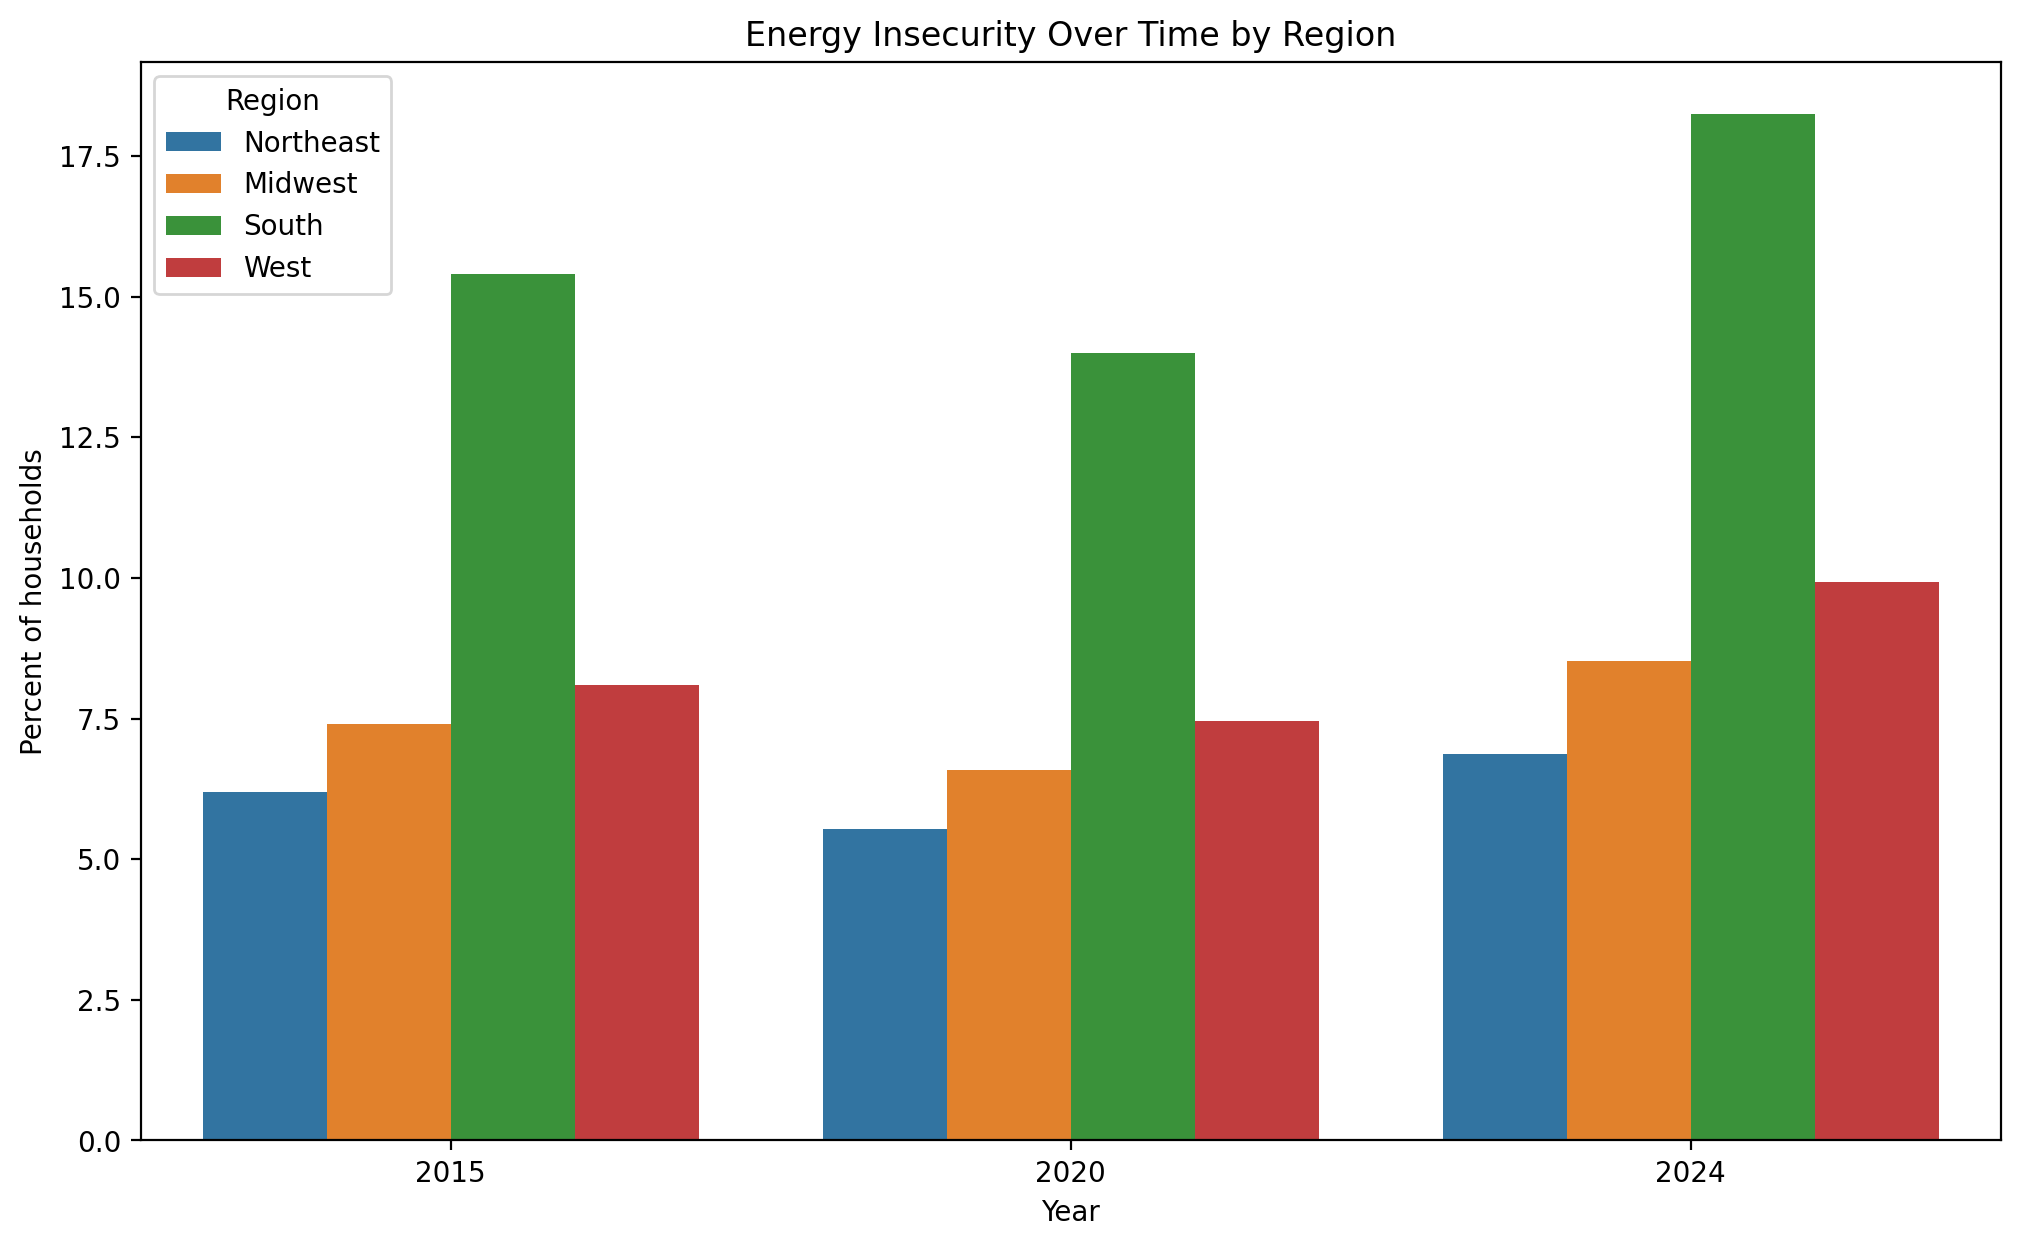

In [39]:
# Generate bar chart for energy insecurity over time by region
regions = ["Northeast", "Midwest", "South", "West"]

df_regions = df_all[df_all["region"].isin(regions)]

sns.barplot(
    data=df_regions,
    x="year",
    y="any_insecurity",
    hue="region",
    order=[2015, 2020, 2024]
)
plt.title("Energy Insecurity Over Time by Region")
plt.xlabel("Year")
plt.ylabel("Percent of households")
plt.legend(title="Region")
plt.show()

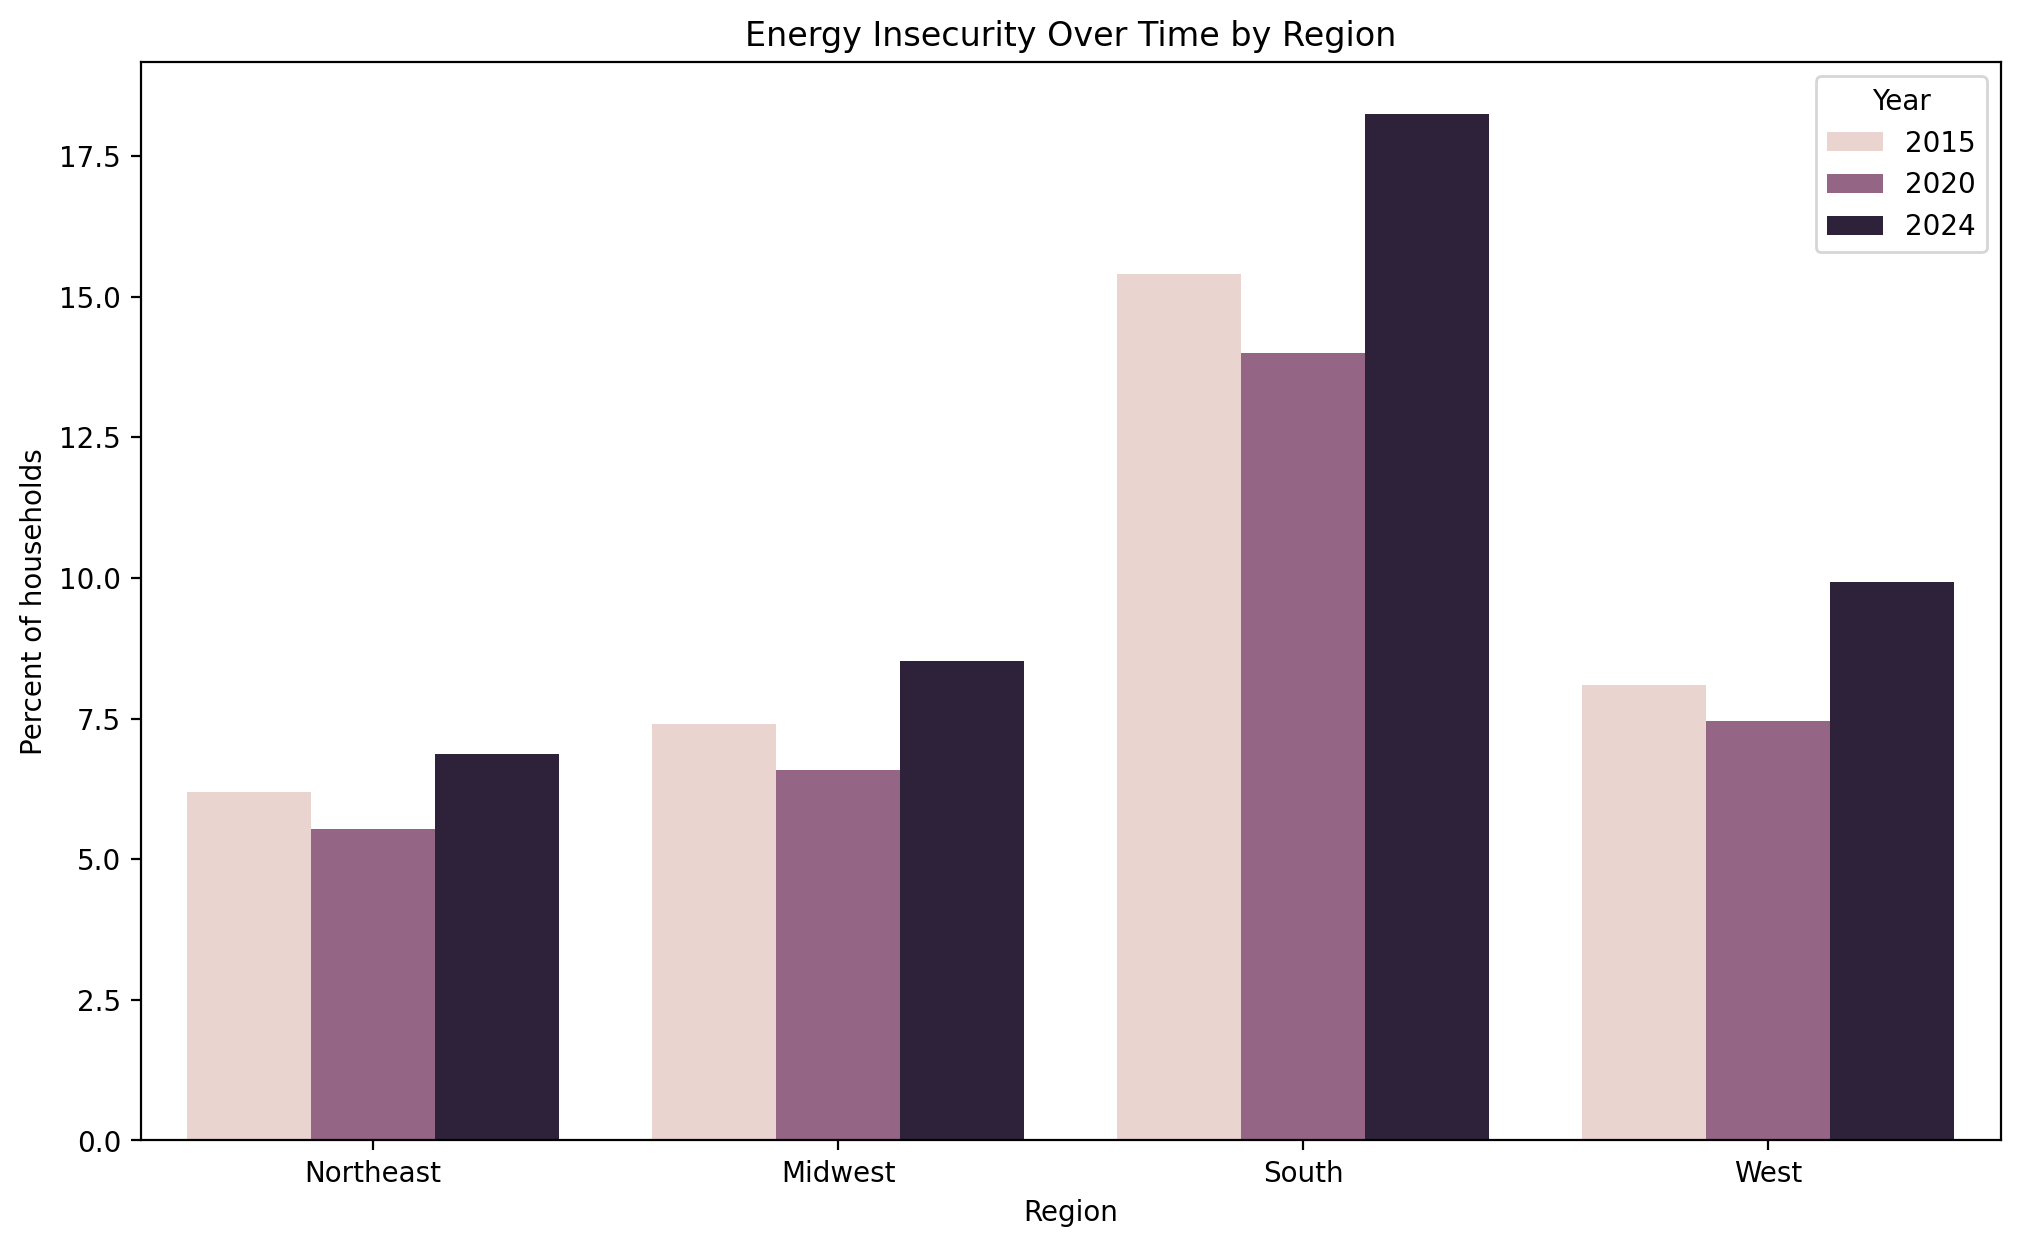

In [40]:
# Another version of the chart above 

regions = ["Northeast", "Midwest", "South", "West"]

df_regions = df_all[df_all["region"].isin(regions)]

sns.barplot(
    data=df_regions,
    x="region",
    y="any_insecurity",
    hue="year",
    order=regions,
    hue_order=[2015, 2020, 2024]
)

plt.title("Energy Insecurity Over Time by Region")
plt.xlabel("Region")
plt.ylabel("Percent of households")
plt.legend(title="Year")
plt.show()